In [1]:
from google.colab import files
uploaded = files.upload()

Saving train_DUMM_dots_commas.csv to train_DUMM_dots_commas.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving test_DUMM_dots_commas.csv to test_DUMM_dots_commas.csv


In [3]:
import os
os.listdir()

['.config',
 'test_DUMM_dots_commas.csv',
 'train_DUMM_dots_commas.csv',
 'sample_data']

                            OLS Regression Results                            
Dep. Variable:           heating_load   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     1076.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:27:44   Log-Likelihood:                -1388.6
No. Observations:                 576   AIC:                             2805.
Df Residuals:                     562   BIC:                             2866.
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    66.49

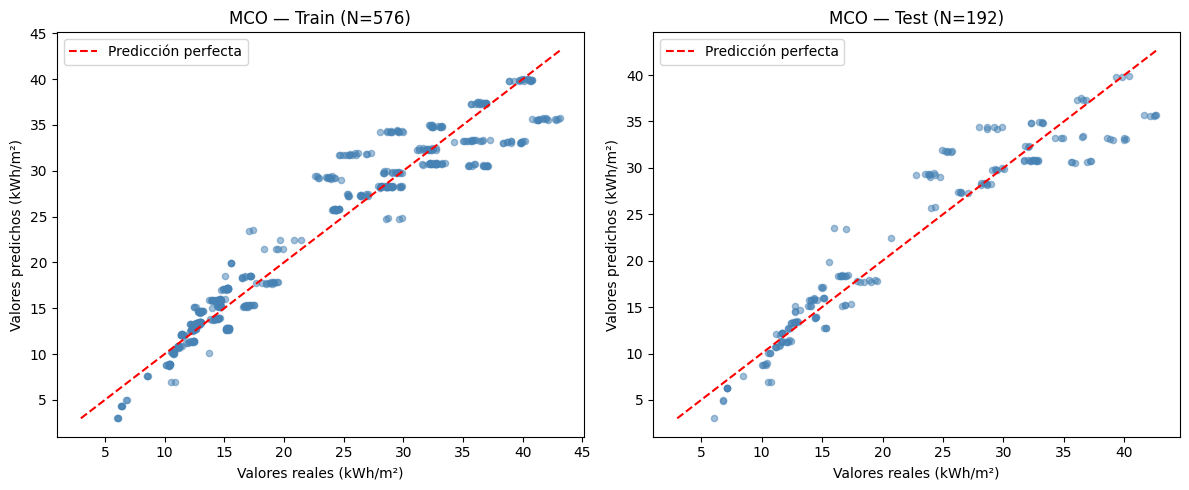

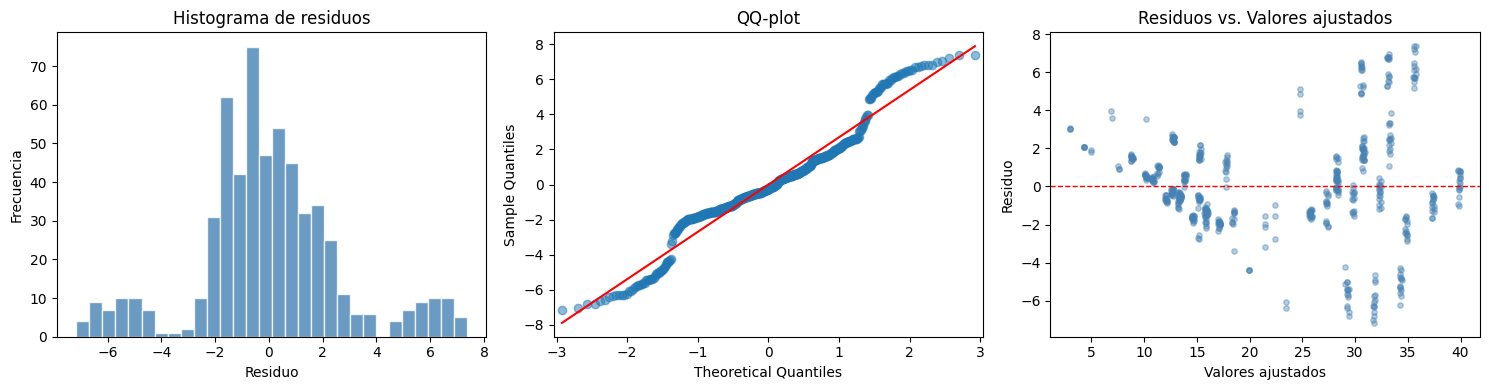


✓ MCO definitivo completado.
  Archivos generados:
  - MCO_predichos_vs_reales.png
  - MCO_diagnostico_residuos.png


In [4]:
# ============================================================
#  MCO DEFINITIVO — Trabajo Final Econometría
#  Base: Tsanas & Xifara (2012) — Heating Load
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Cargar datos ──────────────────────────────────────────
train = pd.read_csv('train_DUMM_dots_commas.csv')
test  = pd.read_csv('test_DUMM_dots_commas.csv')
train.columns = train.columns.str.replace('\ufeff', '')
test.columns  = test.columns.str.replace('\ufeff', '')

TARGET = 'heating_load'
REF    = ['orientation_2', 'glazing_dist_1']  # categorías de referencia

X_train = train.drop(columns=[TARGET] + REF)
y_train = train[TARGET]
X_test  = test.drop(columns=[TARGET] + REF)
y_test  = test[TARGET]

# ── Estimar MCO con HC3 ───────────────────────────────────
Xc_train = sm.add_constant(X_train)
Xc_test  = sm.add_constant(X_test)
modelo   = sm.OLS(y_train, Xc_train).fit(cov_type='HC3')

print(modelo.summary())

# ── Métricas train ────────────────────────────────────────
yp_train = modelo.predict(Xc_train)
yp_test  = modelo.predict(Xc_test)

r2_tr   = r2_score(y_train, yp_train)
rmse_tr = np.sqrt(mean_squared_error(y_train, yp_train))
mae_tr  = mean_absolute_error(y_train, yp_train)

r2_te   = r2_score(y_test, yp_test)
rmse_te = np.sqrt(mean_squared_error(y_test, yp_test))
mae_te  = mean_absolute_error(y_test, yp_test)
mape_te = np.mean(np.abs((y_test - yp_test) / y_test)) * 100

print(f"\n── TRAIN ──")
print(f"R²:   {r2_tr:.4f}")
print(f"RMSE: {rmse_tr:.4f}")
print(f"MAE:  {mae_tr:.4f}")
print(f"\n── TEST ──")
print(f"R²:   {r2_te:.4f}")
print(f"RMSE: {rmse_te:.4f}")
print(f"MAE:  {mae_te:.4f}")
print(f"MAPE: {mape_te:.2f}%")

# ── Intervalos de predicción ──────────────────────────────
pred        = modelo.get_prediction(Xc_test)
pred_df     = pred.summary_frame(alpha=0.05)
cobertura   = np.mean((y_test >= pred_df['obs_ci_lower']) &
                      (y_test <= pred_df['obs_ci_upper'])) * 100
amplitud    = (pred_df['obs_ci_upper'] - pred_df['obs_ci_lower']).mean()

print(f"\n── INTERVALOS DE PREDICCIÓN (95%) ──")
print(f"Cobertura empírica: {cobertura:.1f}%")
print(f"Amplitud media:     {amplitud:.3f} kWh/m²")

# ── Diagnóstico de residuos ───────────────────────────────
resid   = modelo.resid
jb_stat, jb_p = stats.jarque_bera(resid)
sw_stat, sw_p = stats.shapiro(resid[:500])

print(f"\n── DIAGNÓSTICO DE RESIDUOS ──")
print(f"Jarque-Bera: stat={jb_stat:.2f}, p={jb_p:.6f}")
print(f"Shapiro-Wilk: stat={sw_stat:.4f}, p={sw_p:.6f}")


# ── Test de Breusch-Pagan (heteroscedasticidad) ───────────
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(modelo.resid, Xc_train)

print(f"\n── TEST DE BREUSCH-PAGAN ──")
print(f"Estadístico LM: {bp_stat:.4f}")
print(f"p-valor:        {bp_p:.6f}")
print(f"{'✓ No se rechaza homocedasticidad' if bp_p > 0.05 else '✗ Se rechaza homocedasticidad → HC3 justificado'}")

# ── VIF ───────────────────────────────────────────────────
vif = pd.DataFrame({
    'Variable': Xc_train.columns,
    'VIF': [variance_inflation_factor(Xc_train.values, i)
            for i in range(Xc_train.shape[1])]
})
print(f"\n── VIF ──")
print(vif.round(2).to_string(index=False))

# ── GRÁFICO 1: Predichos vs Reales (train y test) ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_r, y_p, tit in zip(
    axes,
    [y_train, y_test],
    [yp_train, yp_test],
    ['Train (N=576)', 'Test (N=192)']
):
    ax.scatter(y_r, y_p, alpha=0.5, s=20, color='steelblue')
    mn = min(y_r.min(), y_p.min())
    mx = max(y_r.max(), y_p.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Predicción perfecta')
    ax.set_xlabel('Valores reales (kWh/m²)')
    ax.set_ylabel('Valores predichos (kWh/m²)')
    ax.set_title(f'MCO — {tit}')
    ax.legend()
plt.tight_layout()
plt.savefig('MCO_predichos_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()

# ── GRÁFICO 2: Diagnóstico de residuos ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma
axes[0].hist(resid, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Histograma de residuos')
axes[0].set_xlabel('Residuo'); axes[0].set_ylabel('Frecuencia')

# QQ-plot
sm.qqplot(resid, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('QQ-plot')

# Residuos vs fitted
axes[2].scatter(modelo.fittedvalues, resid, alpha=0.4, s=15, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--', lw=1)
axes[2].set_title('Residuos vs. Valores ajustados')
axes[2].set_xlabel('Valores ajustados'); axes[2].set_ylabel('Residuo')

plt.tight_layout()
plt.savefig('MCO_diagnostico_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ MCO definitivo completado.")
print("  Archivos generados:")
print("  - MCO_predichos_vs_reales.png")
print("  - MCO_diagnostico_residuos.png")

In [5]:
print(f"Media Y train: {y_train.mean():.4f}")
print(f"D.T. Y train:  {y_train.std():.4f}")
print(f"RSS:           {(modelo.resid**2).sum():.4f}")
print(f"SER:           {np.sqrt((modelo.resid**2).sum() / modelo.df_resid):.4f}")

Media Y train: 22.3432
D.T. Y train:  10.0755
RSS:           4187.4724
SER:           2.7297
